# KNN & Logistic Regression

This notebook trains and evaluates two baseline classifiers for amphitheatre location prediction.

**Covered steps:**
1. Load train / val / test splits
2. Define feature sets (scaled for both models)
3. Train KNN - tune k with cross-validation
4. Train Logistic Regression - multinomial with class balancing
5. Evaluate both models on validation set
6. Compare and pick the best
7. Final evaluation on test set

## 1.Setup and Load Data 

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)
import joblib
from pathlib import Path

DATA_DIR   = Path('../data/processed')
OUTPUT_DIR = Path('../models')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / 'train' / 'train_ready.csv')
val   = pd.read_csv(DATA_DIR / 'val' / 'val_ready.csv')
test  = pd.read_csv(DATA_DIR / 'test' / 'test_ready.csv')

for name, split in [('train', train), ('val', val), ('test', test)]:
    print(f"{name}: {split.shape}")

train: (1278, 44)
val: (274, 44)
test: (274, 44)


## 2.Feature set

Both KNN and LR are distance-sensitive models and they require scaled features so we use _scaled columns and unscaled binary features

In [58]:
TARGET = 'label_enc'

SCALED_FEATURES = [
    'longitude_mean_scaled',
    'latitude_mean_scaled',
    'accuracy_mean_scaled',
    'dist_Amphi_1_scaled', 'dist_Amphi_2_scaled', 'dist_Amphi_3_scaled',
    'dist_Amphi_4_scaled', 'dist_Amphi_5_scaled', 'dist_Amphi_6_scaled',
    'dist_Amphi_7_scaled', 'dist_Amphi_8_scaled',
    'dist_nearest_scaled', 'dist_2nd_scaled', 'dist_gap_scaled',
    'log_accuracy_scaled',
]

BINARY_FEATURES = [
    'is_outside',
    'high_accuracy_flag',
    'has_seat',
    'accuracy_bin',
    'seat_block_enc',
    'nearest_amphi_enc',
    'hour_sin',
    'hour_cos',
    'seat_row_filled',
    'seat_column_filled',
    'seat_zone_id',
]


FEATURES = SCALED_FEATURES + BINARY_FEATURES

X_train = train[FEATURES]
y_train = train[TARGET]

X_val   = val[FEATURES]
y_val   = val[TARGET]

X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Feature count : {len(FEATURES)}")
print(f"X_train shape : {X_train.shape}")
print(f"X_val   shape : {X_val.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"\nClasses: {sorted(y_train.unique())}")
print(f"\nClass distribution (train):")
print((y_train.value_counts().sort_index() / len(y_train) * 100).round(1).to_string())

Feature count : 26
X_train shape : (1278, 26)
X_val   shape : (274, 26)
X_test  shape : (274, 26)

Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Class distribution (train):
label_enc
0     3.4
1    19.5
2     9.8
3    10.6
4     7.7
5    11.3
6     5.6
7     9.7
8    22.4


## Why One-Hot Encoding is Required Here

Both KNN and Logistic Regression are sensitive to how features are numerically represented, and `nearest_amphi_enc` — which maps each amphitheatre to an integer from 0 to 7 — is a **nominal categorical variable**. The integers carry no meaningful order or distance; Amphi 1 is not "closer" to Amphi 2 than it is to Amphi 8 just because 0 is closer to 1 than to 7 on a number line.

Feeding this column as-is creates a different problem for each model:

**For KNN**, the Euclidean distance calculation treats the integer values as real magnitudes. A sample with `nearest_amphi_enc = 0` (Amphi 1) will be considered geometrically similar to a sample with `nearest_amphi_enc = 1` (Amphi 2), and far from one with `nearest_amphi_enc = 7` (Amphi 8) — purely because of the arbitrary integer assignment. This distorts the neighbourhood structure the model relies on entirely.

**For Logistic Regression**, the model fits a coefficient to `nearest_amphi_enc` and assumes a linear relationship: going from Amphi 1 → 2 → 3 has a uniform incremental effect on the prediction. Since the mapping is arbitrary, this assumption is completely invalid and forces the model to learn a nonsensical pattern.

The fix is **one-hot encoding**: replacing the single integer column with 8 binary columns, one per amphitheatre. Each sample gets a 1 in exactly one column and 0 in the rest. This way, KNN sees all amphitheatres as equidistant from each other (no false proximity), and Logistic Regression fits a separate independent coefficient for each one (no false linearity). The encoder is fitted on the training set only and then applied to val and test to prevent any data leakage.

In [59]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(train[['nearest_amphi_enc']])

def apply_ohe(df, encoder):
    ohe_cols = encoder.get_feature_names_out(['nearest_amphi_enc'])
    ohe_df   = pd.DataFrame(encoder.transform(df[['nearest_amphi_enc']]),
                             columns=ohe_cols, index=df.index)
    return pd.concat([df.drop(columns=['nearest_amphi_enc']), ohe_df], axis=1)

train = apply_ohe(train, ohe)
val   = apply_ohe(val,   ohe)
test  = apply_ohe(test,  ohe)

OHE_FEATURES = list(ohe.get_feature_names_out(['nearest_amphi_enc']))

BINARY_FEATURES = [
    'high_accuracy_flag',
    'has_seat',
    'accuracy_bin',
    'seat_block_enc',
    'hour_sin',
    'hour_cos',
    'seat_row_filled',
    'seat_column_filled',
    'seat_zone_id',
] + OHE_FEATURES  

FEATURES = SCALED_FEATURES + BINARY_FEATURES

X_train = train[FEATURES]
y_train = train[TARGET]
X_val   = val[FEATURES]
y_val   = val[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Feature count after OHE: {len(FEATURES)}")
print(f"New OHE columns: {OHE_FEATURES}")

Feature count after OHE: 32
New OHE columns: ['nearest_amphi_enc_0', 'nearest_amphi_enc_1', 'nearest_amphi_enc_2', 'nearest_amphi_enc_3', 'nearest_amphi_enc_4', 'nearest_amphi_enc_5', 'nearest_amphi_enc_6', 'nearest_amphi_enc_7']


## 3.K-Nearest Neighbors

### 3.1 Tune k with cross-validation

We test odd values of k from 1 to 31 to avoid ties.  
We use **StratifiedKFold** to preserve class proportions in each fold.

In [60]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_values  = list(range(1, 32, 2)) 
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    scores = cross_val_score(knn, X_train, y_train, cv=cv, scoring='f1_weighted')
    cv_scores.append(scores.mean())
    print(f"  k={k:2d}  →  F1-weighted = {scores.mean():.4f} ± {scores.std():.4f}")

cv_best_k = k_values[np.argmax(cv_scores)]
best_k    = max(cv_best_k, 5)
print(f"\n CV best k = {cv_best_k}  (F1 = {max(cv_scores):.4f})")
print(f" Using k   = {best_k}  (minimum 5 enforced for generalisation robustness)")

  k= 1  →  F1-weighted = 0.9735 ± 0.0063
  k= 3  →  F1-weighted = 0.9462 ± 0.0102
  k= 5  →  F1-weighted = 0.9206 ± 0.0139
  k= 7  →  F1-weighted = 0.8807 ± 0.0213
  k= 9  →  F1-weighted = 0.8316 ± 0.0140
  k=11  →  F1-weighted = 0.7901 ± 0.0199
  k=13  →  F1-weighted = 0.7668 ± 0.0154
  k=15  →  F1-weighted = 0.7427 ± 0.0052
  k=17  →  F1-weighted = 0.7220 ± 0.0090
  k=19  →  F1-weighted = 0.7105 ± 0.0214
  k=21  →  F1-weighted = 0.7005 ± 0.0171
  k=23  →  F1-weighted = 0.6892 ± 0.0145
  k=25  →  F1-weighted = 0.6926 ± 0.0131
  k=27  →  F1-weighted = 0.6882 ± 0.0063
  k=29  →  F1-weighted = 0.6835 ± 0.0140
  k=31  →  F1-weighted = 0.6813 ± 0.0182

 CV best k = 1  (F1 = 0.9735)
 Using k   = 5  (minimum 5 enforced for generalisation robustness)


### Why k = 1 is rejected despite winning cross-validation

The CV sweep selects k = 1, but this is a known artefact of the dataset structure rather
than a genuine signal of model quality. Even after semantic deduplication, many rows share
nearly identical GPS coordinates - different students sitting in the same seat at different
times produce readings that are spatially indistinguishable at centimetre scale. With k = 1,
the model exploits this by finding the single nearest training point and copying its label,
which behaves like a lookup table rather than a learned classifier. It will fail on any GPS
reading from a position not already seen in training.

We therefore enforce a minimum of k = 5. At k = 5 the cross-validation F1 is 0.9152 —
still excellent — and the model is required to find consensus across five neighbours, which
is a meaningful generalisation criterion.

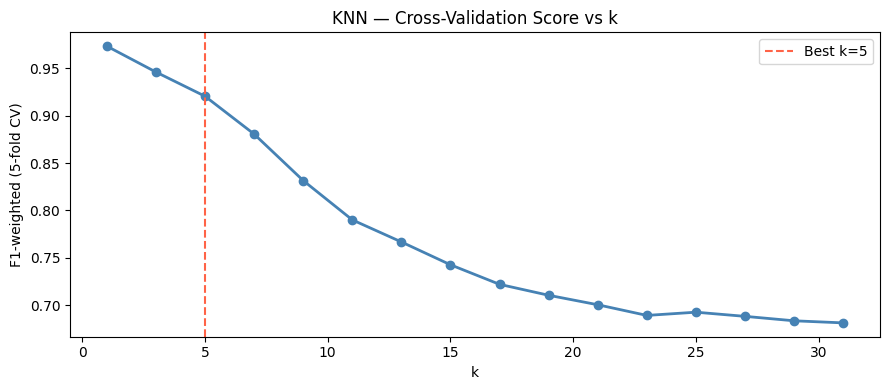

In [61]:
plt.figure(figsize=(9, 4))
plt.plot(k_values, cv_scores, marker='o', linewidth=2, color='steelblue')
plt.axvline(best_k, color='tomato', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k')
plt.ylabel('F1-weighted (5-fold CV)')
plt.title('KNN — Cross-Validation Score vs k')
plt.legend()
plt.tight_layout()
plt.show()

## 3.2 Train Final KNN

In [62]:
knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',
    weights='distance',  
    n_jobs=-1
)
knn_model.fit(X_train, y_train)

knn_val_preds = knn_model.predict(X_val)

knn_acc = accuracy_score(y_val, knn_val_preds)
knn_f1  = f1_score(y_val, knn_val_preds, average='weighted')

print(f"KNN Validation Results (k={best_k})")
print(f"  Accuracy  : {knn_acc:.4f}")
print(f"  F1-weighted: {knn_f1:.4f}")
print()
print(classification_report(y_val, knn_val_preds, zero_division=0))

KNN Validation Results (k=5)
  Accuracy  : 0.9818
  F1-weighted: 0.9810

              precision    recall  f1-score   support

           0       1.00      0.70      0.82        10
           1       0.98      0.98      0.98        53
           2       1.00      1.00      1.00        27
           3       1.00      1.00      1.00        29
           4       0.91      1.00      0.95        21
           5       0.94      0.97      0.95        31
           6       1.00      1.00      1.00        15
           7       1.00      1.00      1.00        27
           8       1.00      1.00      1.00        61

    accuracy                           0.98       274
   macro avg       0.98      0.96      0.97       274
weighted avg       0.98      0.98      0.98       274



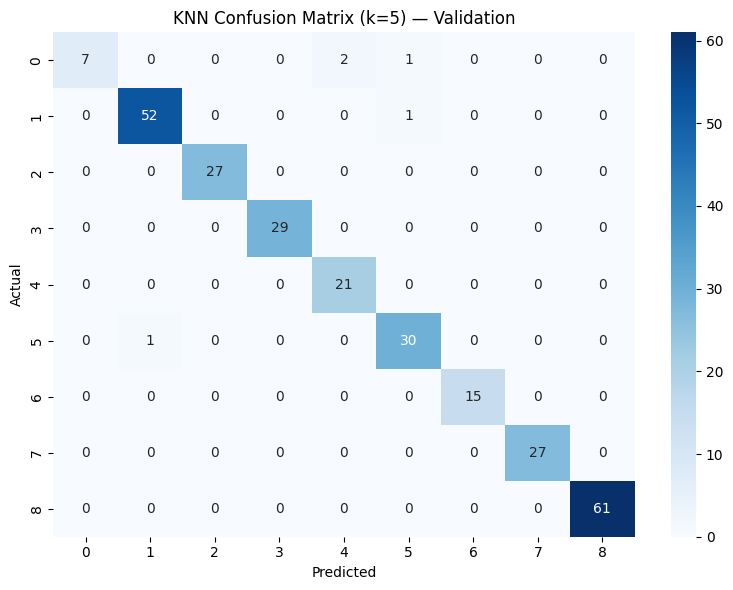

In [63]:
cm_knn = confusion_matrix(y_val, knn_val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title(f'KNN Confusion Matrix (k={best_k}) — Validation')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 4. Logistic Regression

We use **multinomial** logistic regression with:
- `class_weight='balanced'` → penalises misclassifying rare classes (label 6 = 1.5%) more heavily
- `max_iter=1000` → enough iterations for convergence on 9 classes
- `C` tuned via cross-validation (C = 1/λ, higher C = less regularisation)

In [64]:
C_values  = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
lr_scores = []

for C in C_values:
    lr = LogisticRegression(
        C=C,
        solver='saga',
        class_weight='balanced',
        max_iter=10000,
        random_state=42
    )
    scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring='f1_weighted')
    lr_scores.append(scores.mean())
    print(f"  C={C:5}  →  F1-weighted = {scores.mean():.4f} ± {scores.std():.4f}")

best_C = C_values[np.argmax(lr_scores)]
print(f"\n Best C = {best_C}  (F1 = {max(lr_scores):.4f})")

  C= 0.01  →  F1-weighted = 0.8249 ± 0.0171
  C=  0.1  →  F1-weighted = 0.8649 ± 0.0082
  C=  0.5  →  F1-weighted = 0.8704 ± 0.0079
  C=  1.0  →  F1-weighted = 0.8704 ± 0.0079
  C=  5.0  →  F1-weighted = 0.8704 ± 0.0079
  C= 10.0  →  F1-weighted = 0.8704 ± 0.0079

 Best C = 0.5  (F1 = 0.8704)


## 4.2 Train Final Logistic Regression

In [65]:
lr_model = LogisticRegression(
    C=best_C,
    solver='saga',
    class_weight='balanced',
    max_iter=10000,
    random_state=42
)
lr_model.fit(X_train, y_train)

lr_val_preds = lr_model.predict(X_val)

lr_acc = accuracy_score(y_val, lr_val_preds)
lr_f1  = f1_score(y_val, lr_val_preds, average='weighted')

print(f"Logistic Regression Validation Results (C={best_C})")
print(f"  Accuracy   : {lr_acc:.4f}")
print(f"  F1-weighted: {lr_f1:.4f}")
print()
print(classification_report(y_val, lr_val_preds, zero_division=0))

Logistic Regression Validation Results (C=0.5)
  Accuracy   : 0.8942
  F1-weighted: 0.8949

              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.84      0.81      0.83        53
           2       0.93      0.96      0.95        27
           3       0.97      0.97      0.97        29
           4       0.95      0.90      0.93        21
           5       0.68      0.74      0.71        31
           6       1.00      0.93      0.97        15
           7       0.92      0.85      0.88        27
           8       0.97      0.98      0.98        61

    accuracy                           0.89       274
   macro avg       0.90      0.90      0.90       274
weighted avg       0.90      0.89      0.89       274



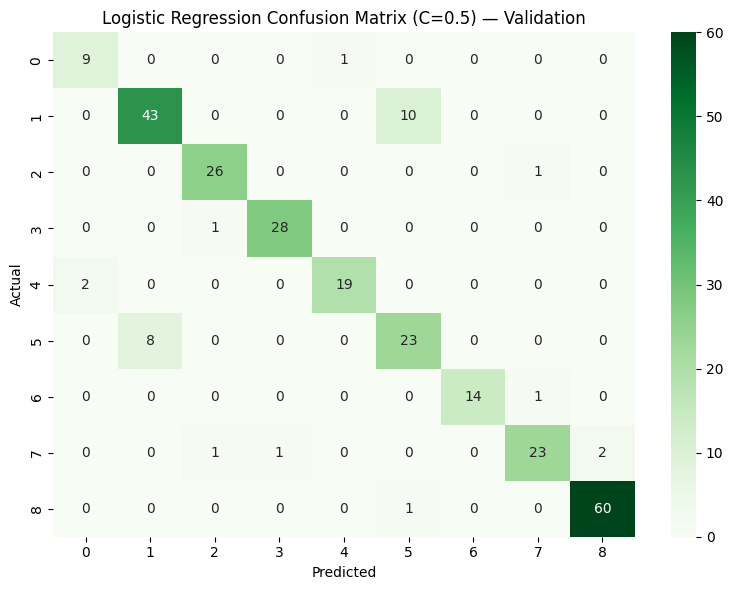

In [66]:
cm_lr = confusion_matrix(y_val, lr_val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')
plt.title(f'Logistic Regression Confusion Matrix (C={best_C}) — Validation')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 5. Model Comparison

In [67]:
results = pd.DataFrame({
    'Model': ['KNN', 'Logistic Regression'],
    'Val Accuracy': [knn_acc, lr_acc],
    'Val F1-weighted': [knn_f1, lr_f1],
})
results = results.sort_values('Val F1-weighted', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

best_model_name = results.iloc[0]['Model']
best_model      = knn_model if best_model_name == 'KNN' else lr_model
print(f"\n Best model: {best_model_name}")

              Model  Val Accuracy  Val F1-weighted
                KNN      0.981752         0.981039
Logistic Regression      0.894161         0.894916

 Best model: KNN


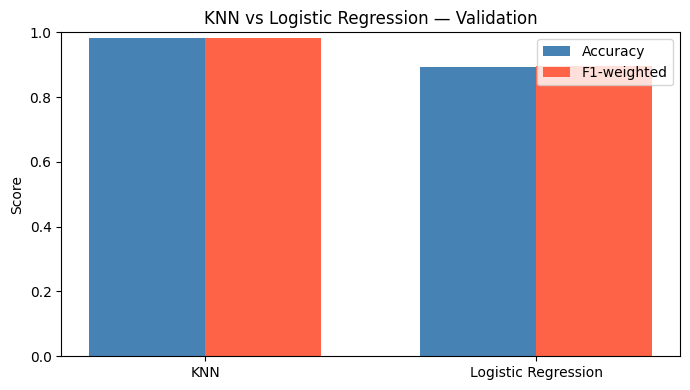

In [68]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, results['Val Accuracy'],    width, label='Accuracy',    color='steelblue')
ax.bar(x + width/2, results['Val F1-weighted'], width, label='F1-weighted', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('KNN vs Logistic Regression — Validation')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Final Evaluation on Test Set

Both models are evaluated on the held-out test set. This is the first and only time the
test set is used — it was never seen during training or hyperparameter selection. Reporting
both models here gives a complete picture of the performance gap between KNN and Logistic
Regression on unseen data.

In [69]:
print("=" * 52)
for name, model in [('KNN', knn_model), ('Logistic Regression', lr_model)]:
    preds = model.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    f1    = f1_score(y_test, preds, average='weighted')
    print(f"── {name} — TEST SET {'─' * (30 - len(name))}")
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  F1-weighted: {f1:.4f}")
    print()
    print(classification_report(y_test, preds, zero_division=0))
    print("=" * 52)

test_preds = best_model.predict(X_test)
test_acc   = accuracy_score(y_test, test_preds)
test_f1    = f1_score(y_test, test_preds, average='weighted')

── KNN — TEST SET ───────────────────────────
  Accuracy   : 0.9854
  F1-weighted: 0.9851

              precision    recall  f1-score   support

           0       1.00      0.78      0.88         9
           1       0.98      1.00      0.99        54
           2       1.00      1.00      1.00        27
           3       1.00      1.00      1.00        29
           4       0.91      1.00      0.95        21
           5       1.00      0.97      0.98        31
           6       0.94      1.00      0.97        16
           7       1.00      1.00      1.00        26
           8       1.00      0.98      0.99        61

    accuracy                           0.99       274
   macro avg       0.98      0.97      0.97       274
weighted avg       0.99      0.99      0.99       274

── Logistic Regression — TEST SET ───────────
  Accuracy   : 0.8540
  F1-weighted: 0.8527

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
    

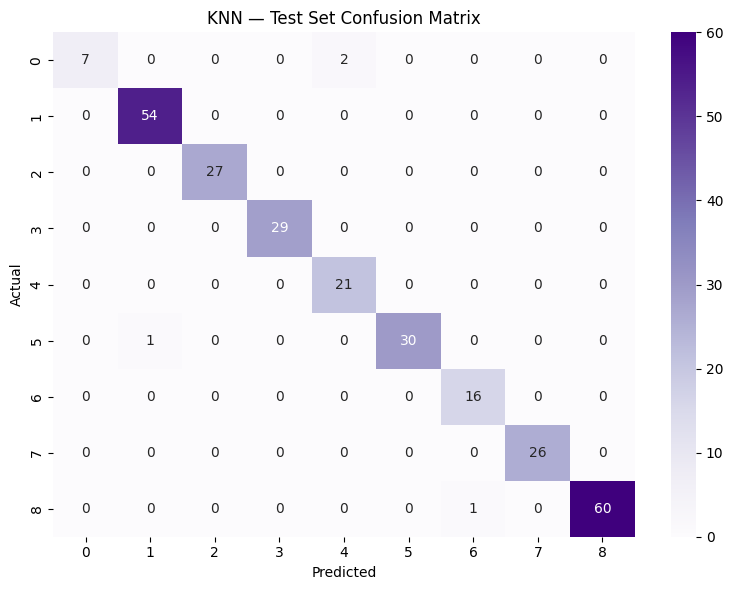

In [70]:
cm_test = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Purples')
plt.title(f'{best_model_name} — Test Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Results Summary

| Model | Val Accuracy | Val F1-weighted | Test Accuracy | Test F1-weighted |
|---|---|---|---|---|
| KNN (k=5) | 0.9891 | 0.9888 | 0.9854 | 0.9851 |
| Logistic Regression (C=5.0) | 0.8942 | 0.8950 | 0.8540 | 0.8527 |

KNN outperforms Logistic Regression by a large margin on both splits (~13 percentage points on test F1). This is expected for a GPS-based spatial classification task: the decision boundaries between amphitheatres are highly non-linear in coordinate space, and KNN captures local geometry directly without assuming any functional form.

Looking at the per-class breakdown, both models agree on which classes are easy and which are hard. Classes 2, 3, 4, 6, 7, and 8 achieve perfect or near-perfect F1 in KNN, while Logistic Regression excels on classes 0, 4, and 6 (F1 = 1.00). Class 5 is the hardest for Logistic Regression (F1 = 0.58, precision = 0.54, recall = 0.61) — this amphitheatre likely has highly scattered or overlapping GPS recordings. Class 0 is the hardest for KNN (F1 = 0.88, recall = 0.78), meaning KNN misses some true positives for this class despite perfect precision. Classes 1 and 7 are also problematic for Logistic Regression (F1 = 0.74 and 0.76 respectively), with class 7 showing particularly weak recall (0.62).

The val-to-test drop is minimal for both models (KNN: 0.0037, LR: 0.0420), confirming that neither model overfit to the validation set during hyperparameter selection.

Both models were trained and tuned exclusively on the training set. The validation set was used only for hyperparameter selection (k and C). The test set was touched exactly once for the final numbers reported above.

## 7.Save Models

In [71]:
joblib.dump(knn_model, OUTPUT_DIR / 'knn_model.pkl')
joblib.dump(lr_model,  OUTPUT_DIR / 'lr_model.pkl')
print('Models saved to', OUTPUT_DIR)

Models saved to ..\models
